In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_excel("Coffee Shop Sales.xlsx")
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [24]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB
None
       transaction_id               transaction_date  transaction_qty  \
count   149116

In [37]:
# Check missing values
print(df.isnull().sum())
print(df.duplicated().sum())

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
total_sales         0
year                0
month               0
day                 0
weekday             0
hour                0
is_weekend          0
dtype: int64
0


In [33]:
# Convert date & time
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.time

# Drop duplicates
df = df.drop_duplicates()

# Fix data types
df['transaction_qty'] = df['transaction_qty'].astype(int)
df['unit_price'] = df['unit_price'].astype(float)


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB


In [35]:
# Create total sales column
df['total_sales'] = df['transaction_qty'] * df['unit_price']

# Extract time-based features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day'] = df['transaction_date'].dt.day
df['weekday'] = df['transaction_date'].dt.day_name()

# Hour from time
df['hour'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.hour

# Weekend flag
df['is_weekend'] = df['weekday'].isin(['Saturday', 'Sunday'])

In [36]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,total_sales,year,month,day,weekday,hour,is_weekend
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,2023,1,1,Sunday,7,True
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2023,1,1,Sunday,7,True
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,2023,1,1,Sunday,7,True
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,2023,1,1,Sunday,7,True
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2023,1,1,Sunday,7,True


In [18]:
total_revenue = df['total_sales'].sum()
print(total_revenue)

698812.3300000001


In [12]:
store_sales = df.groupby('store_location')['total_sales'].sum().sort_values()
store_sales

store_location
Lower Manhattan    230057.25
Astoria            232243.91
Hell's Kitchen     236511.17
Name: total_sales, dtype: float64

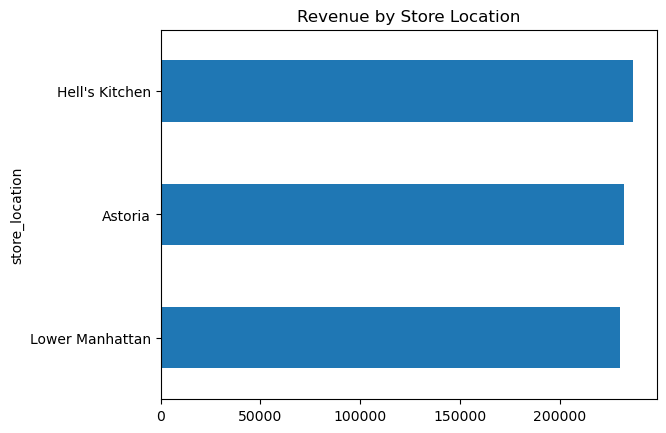

In [13]:
store_sales.plot(kind='barh')
plt.title("Revenue by Store Location")
plt.show()

In [17]:
daily_sales = df.groupby('transaction_date')['total_sales'].sum()
daily_sales

transaction_date
2023-01-01    2508.20
2023-01-02    2403.35
2023-01-03    2565.00
2023-01-04    2220.10
2023-01-05    2418.85
               ...   
2023-06-26    5875.90
2023-06-27    5975.65
2023-06-28    4728.90
2023-06-29    4450.75
2023-06-30    5481.32
Name: total_sales, Length: 181, dtype: float64

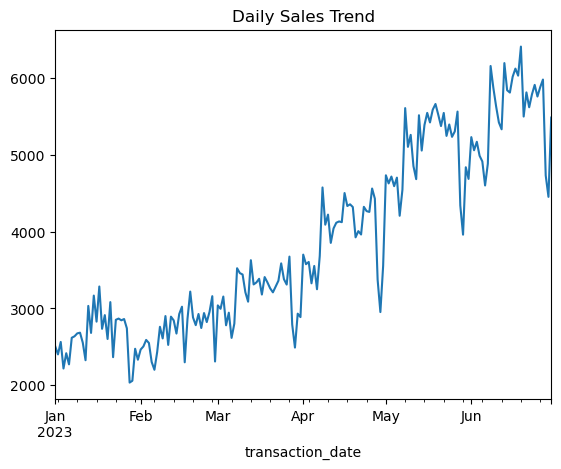

In [18]:
daily_sales.plot()
plt.title("Daily Sales Trend")
plt.show()

In [19]:
monthly_sales = df.groupby('month')['total_sales'].sum()
monthly_sales

month
1     81677.74
2     76145.19
3     98834.68
4    118941.08
5    156727.76
6    166485.88
Name: total_sales, dtype: float64

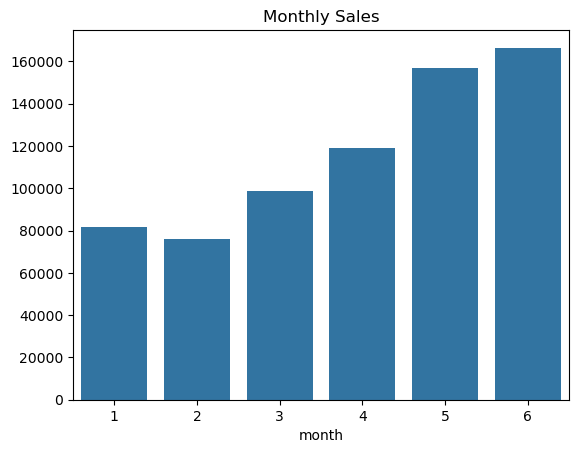

In [20]:
sns.barplot(x=monthly_sales.index, y=monthly_sales.values)
plt.title("Monthly Sales")
plt.show()

In [21]:
category_sales = df.groupby('product_category')['total_sales'].sum()
category_sales

product_category
Bakery                 82315.64
Branded                13607.00
Coffee                269952.45
Coffee beans           40085.25
Drinking Chocolate     72416.00
Flavours                8408.80
Loose Tea              11213.60
Packaged Chocolate      4407.64
Tea                   196405.95
Name: total_sales, dtype: float64

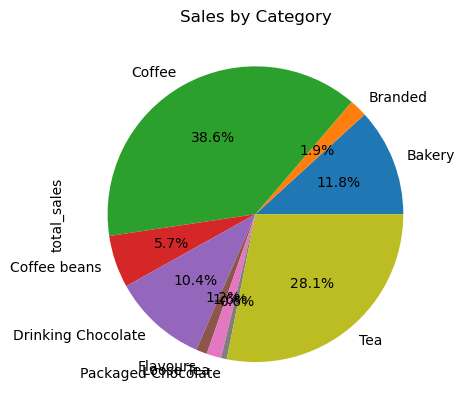

In [22]:
category_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Category")
plt.show()

In [23]:
top_products = df.groupby('product_detail')['total_sales'].sum().nlargest(10)
top_products

product_detail
Sustainably Grown Organic Lg    21151.75
Dark chocolate Lg               21006.00
Latte Rg                        19112.25
Cappuccino Lg                   17641.75
Morning Sunrise Chai Lg         17384.00
Latte                           17257.50
Jamaican Coffee River Lg        16481.25
Sustainably Grown Organic Rg    16233.75
Cappuccino                      15997.50
Brazilian Lg                    15109.50
Name: total_sales, dtype: float64

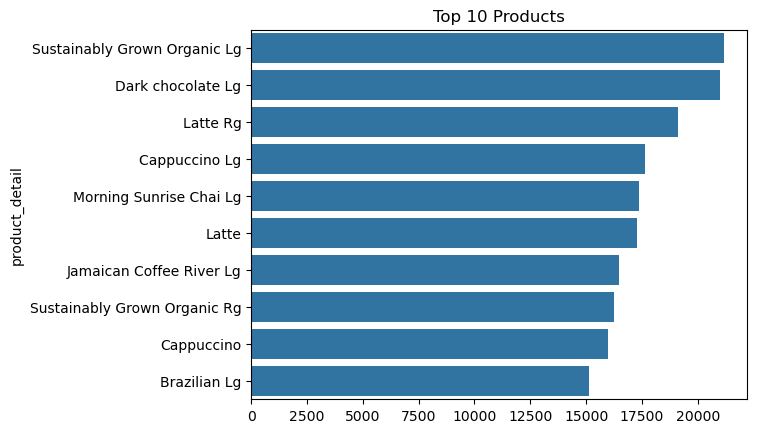

In [24]:
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Products")
plt.show()

In [25]:
hourly_sales = df.groupby('hour')['total_sales'].sum()
hourly_sales

hour
6     21900.27
7     63526.47
8     82699.87
9     85169.53
10    88673.39
11    46319.14
12    40192.79
13    40367.45
14    41304.74
15    41733.10
16    41122.75
17    40134.31
18    34286.20
19    28446.68
20     2935.64
Name: total_sales, dtype: float64

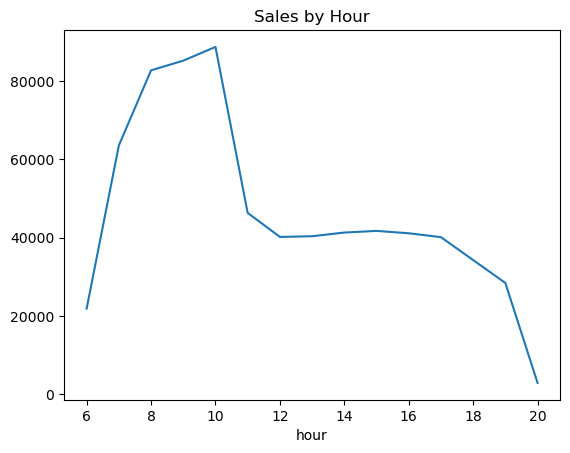

In [26]:
sns.lineplot(x=hourly_sales.index, y=hourly_sales.values)
plt.title("Sales by Hour")
plt.show()

In [27]:
weekend_sales = df.groupby('is_weekend')['total_sales'].sum()
weekend_sales

is_weekend
False    503587.54
True     195224.79
Name: total_sales, dtype: float64

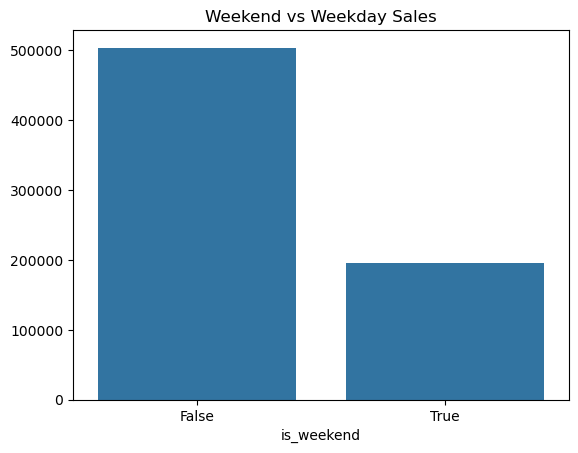

In [28]:
sns.barplot(x=weekend_sales.index, y=weekend_sales.values)
plt.title("Weekend vs Weekday Sales")
plt.show()

In [29]:
weekday_sales = df.groupby('weekday')['total_sales'].sum()
weekday_sales

weekday
Friday       101373.00
Monday       101677.28
Saturday      96894.48
Sunday        98330.31
Thursday     100767.78
Tuesday       99455.94
Wednesday    100313.54
Name: total_sales, dtype: float64

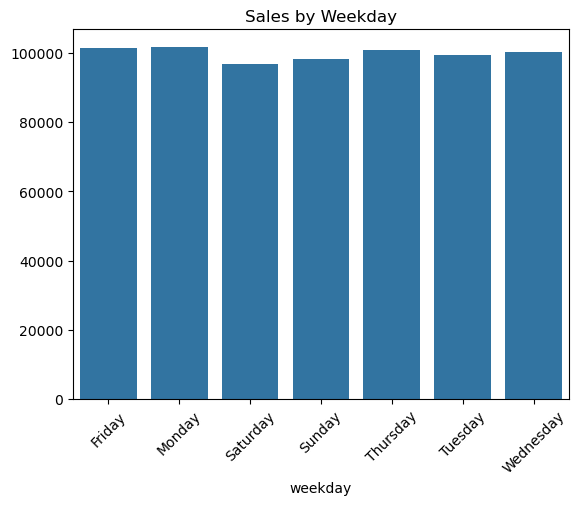

In [30]:
sns.barplot(x=weekday_sales.index, y=weekday_sales.values)
plt.xticks(rotation=45)
plt.title("Sales by Weekday")
plt.show()

In [31]:
avg_order_value = df.groupby('transaction_id')['total_sales'].sum().mean()
print(avg_order_value)

4.6863671906435265


In [32]:
qty_category = df.groupby('product_category')['transaction_qty'].sum()
qty_category

product_category
Bakery                23214
Branded                 776
Coffee                89250
Coffee beans           1828
Drinking Chocolate    17457
Flavours              10511
Loose Tea              1210
Packaged Chocolate      487
Tea                   69737
Name: transaction_qty, dtype: int64

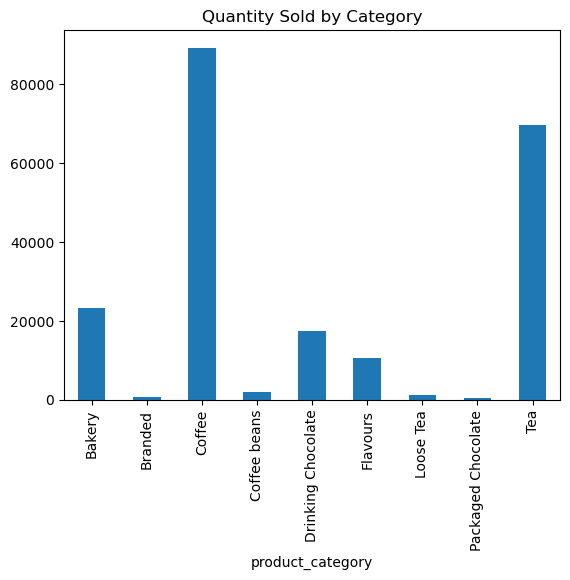

In [33]:
qty_category.plot(kind='bar')
plt.title("Quantity Sold by Category")
plt.show()

In [34]:
store_transactions = df.groupby('store_location')['transaction_id'].count()
store_transactions

store_location
Astoria            50599
Hell's Kitchen     50735
Lower Manhattan    47782
Name: transaction_id, dtype: int64

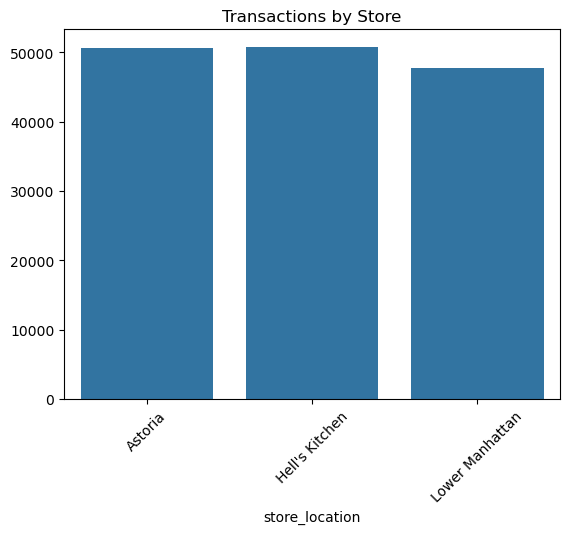

In [35]:
sns.barplot(x=store_transactions.index, y=store_transactions.values)
plt.xticks(rotation=45)
plt.title("Transactions by Store")
plt.show()

In [36]:
pivot = df.pivot_table(values='total_sales', index='weekday', columns='hour', aggfunc='sum')
pivot

hour,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
weekday,,,,,,,,,,,,,,,
Friday,3385.73,9386.04,11746.65,12750.00,13155.66,6827.84,5685.49,5499.49,5840.33,6098.13,5654.93,5687.14,5139.84,4128.20,387.53
Monday,3098.58,9516.52,11604.69,11898.33,12427.25,7179.09,6139.64,5771.26,6463.31,6159.49,6139.96,5927.35,5006.19,4015.22,330.40
Saturday,2913.85,8775.02,11370.86,11333.85,12736.48,6361.41,5957.75,5549.45,5626.89,5946.50,5825.73,5444.70,4642.40,3970.96,438.63
Sunday,3320.73,8892.09,11615.54,12388.75,12382.75,6118.99,5622.99,5908.18,5765.62,5614.75,5728.46,5788.39,4792.48,4006.71,383.88
Thursday,3464.90,9209.23,11420.49,10963.73,12091.09,6898.55,6073.93,5972.46,6114.61,6087.68,6400.13,6027.33,5234.58,4529.10,279.97
Tuesday,2320.25,8841.71,12950.19,13588.47,13497.68,5877.41,5172.64,5443.46,5621.56,5852.24,5723.78,5609.85,4304.36,3967.94,684.40
Wednesday,3396.23,8905.86,11991.45,12246.40,12382.48,7055.85,5540.35,6223.15,5872.42,5974.31,5649.76,5649.55,5166.35,3828.55,430.83


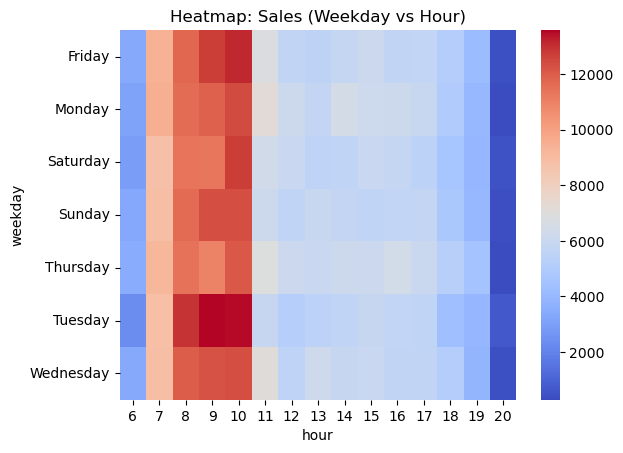

In [37]:
sns.heatmap(pivot, cmap='coolwarm')
plt.title("Heatmap: Sales (Weekday vs Hour)")
plt.show()

In [38]:
type_sales = df.groupby('product_type')['total_sales'].sum().nlargest(10)
type_sales

product_type
Barista Espresso         91406.20
Brewed Chai tea          77081.95
Hot chocolate            72416.00
Gourmet brewed coffee    70034.60
Brewed Black tea         47932.00
Brewed herbal tea        47539.50
Premium brewed coffee    38781.15
Organic brewed coffee    37746.50
Scone                    36866.12
Drip coffee              31984.00
Name: total_sales, dtype: float64

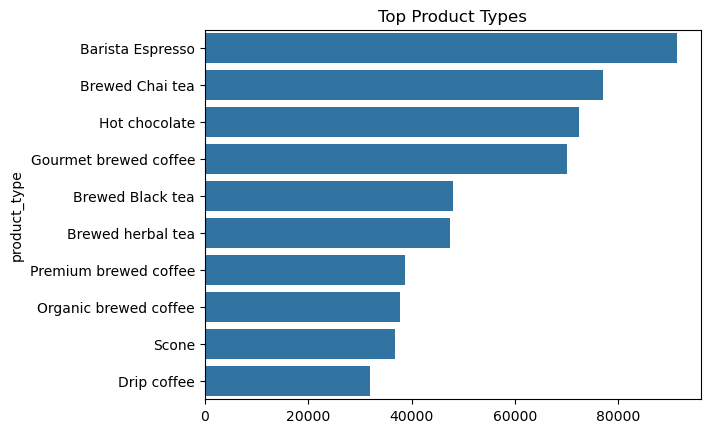

In [39]:
sns.barplot(x=type_sales.values, y=type_sales.index)
plt.title("Top Product Types")
plt.show()

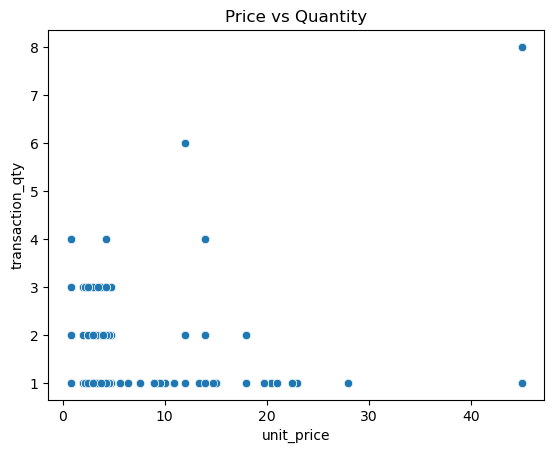

In [40]:
sns.scatterplot(data=df, x='unit_price', y='transaction_qty')
plt.title("Price vs Quantity")
plt.show()

#### ------------------------------------------------------------------------------------------------------------
### REPORTS ON THE ANALYSIS :
- The total revenue generated by the coffee shop during the period January to June 2023 was approximately 698,812.33.
- Among all store locations, Hell’s Kitchen generated the highest revenue (236,511.17), followed by Astoria (232,243.91) and Lower Manhattan (230,057.25). The difference is small, showing all stores performed quite consistently.
- From the monthly sales analysis, June recorded the highest sales (166,485.88), followed by May (156,727.76). January and February had the lowest sales, indicating growth over time.
Coffee was the most profitable category, contributing 269,952.45, followed by Tea (196,405.95) and Bakery (82,315.64). Categories like packaged chocolate and flavours contributed very little.
In terms of quantity sold, Coffee (89,250 units) and Tea (69,737 units) dominated sales, showing strong customer preference for beverages.
- The top-selling product was “Sustainably Grown Organic Lg” (21,151.75), followed closely by “Dark Chocolate Lg” (21,006.00) and “Latte Rg” (19,112.25).
From hourly sales analysis, 10 AM generated the highest revenue (88,673.39), followed by 9 AM and 8 AM, indicating that mornings are the busiest time for the coffee shop.
Sales dropped significantly after evening hours, with very low revenue at 8 PM (2,935.64).
Weekday sales (503,587.54) were much higher than weekend sales (195,224.79), showing that most customers visit during working days.
- Among weekdays, Monday (101,677.28) and Friday (101,373.00) had the highest sales, while Tuesday had slightly lower sales (99,455.94).
- The average order value was approximately 4.69, indicating that customers typically spend a small amount per transaction.
- The store with the highest number of transactions was Hell’s Kitchen (50,735 transactions), followed by Astoria (50,599) and Lower Manhattan (47,782).
- From the heatmap analysis, it was clearly observed that morning hours (8 AM – 10 AM) across all weekdays had the highest sales activity.
- In product type analysis, Barista Espresso generated the highest revenue (91,406.20), followed by Brewed Chai Tea (77,081.95) and Hot Chocolate (72,416.00).
- From the price vs quantity scatter plot, it was observed that lower-priced items are sold in higher quantities, while higher-priced items are sold less frequently.
#### ------------------------------------------------------------------------------------------------------------
### Conclusion :
- During the period January to June 2023, the coffee shop showed steady growth in sales, with the highest performance in the later months, especially May and June.
- Beverages, especially coffee and tea, were the most popular products, contributing the majority of -revenue and quantity sold.
- Morning hours (around 8 AM to 10 AM) were the busiest, indicating that customers mostly visit the shop during breakfast or before work.
- Weekdays generated significantly higher sales than weekends, which suggests that the business depends more on regular working-day customers.
- Among all stores, Hell’s Kitchen performed slightly better, but overall all locations had similar performance, showing balanced operations.
- The average order value is relatively low, meaning customers usually purchase small items rather than large orders.
- One key insight is that pricing affects demand, as lower-priced products are sold more frequently than expensive ones.
- Overall, the analysis shows that time of day, product category, and pricing play a major role in sales performance. Focusing on peak hours and popular products can help improve business strategy and increase revenue.